# HSC Analysis

> This is a worked example of measuring the ICL in images from the HSC-SSP deep survey.

In [ ]:
#| default_exp hsc.analysis

In the following we will assume the require data has already been downloaded and prepared by following the procedure in [HSC Preparation](01_hsc_preparation.ipynb). 

In [ ]:
local_data_path = '/Users/spb/data/hsc/'

Get an image to demonstrate the process

In [ ]:
from nicl.hsc.preparation import get_f21_table2, f21_cluster_image

In [ ]:
cluster = get_f21_table2()[0]
filter = "i"

In [ ]:
img, mask, sigma = f21_cluster_image(cluster['XCS ID'], filter, local_data_path, return_hdus=True)

/Users/spb/data/hsc/XMMXCS_J022456.1-050802.0/XMMXCS_J022456.1-050802.0_i.fits


## Parameters

We define all the key parameters here.

In [ ]:
detection_pars = {"nsigma": 3.0,
                  "background": 0.0,
                  "smooth_sigma": 3.0,
                  "detect_npixels": 6,
                  "deblend_npixels": 6,
                  "deblend_nlevels": 32,
                  "deblend_contrast": .01}

## Masks

### Bad pixel mask

In [ ]:
#! exports
import numpy as np

def create_bad_pixel_mask(mask):
    """Produces a bad pixel mask from a HSC-SSP bit-encoded mask"""
    mask_names = ["MP_BAD", "MP_SAT", "MP_NO_DATA"]
    mask_array = np.zeros(mask.data.shape, dtype=bool)
    for mask_name in mask_names:
        mask_bit = mask.header[mask_name]
        mask_array |= mask.data & (1 << mask_bit) != 0
    return mask_array

In [ ]:
bad_pixel_mask = create_bad_pixel_mask(mask)
print(
    f"Bad pixel masked fraction: {100 * bad_pixel_mask.sum() / bad_pixel_mask.size:.2f}%"
)

Bad pixel masked fraction: 0.73%


In [ ]:
import matplotlib.pyplot as plt
from astropy.visualization import AsinhStretch, ImageNormalize

In [ ]:
def plot_mask(img, mask):
    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    norm = ImageNormalize(vmin=-0.01, vmax=10, stretch=AsinhStretch(0.01))
    ax[0].imshow(img, norm=norm)
    ax[1].imshow(np.where(mask, 0, img), norm=norm)
    ax[2].imshow(mask)
    for a in ax:
        a.axis("off")
    plt.tight_layout()

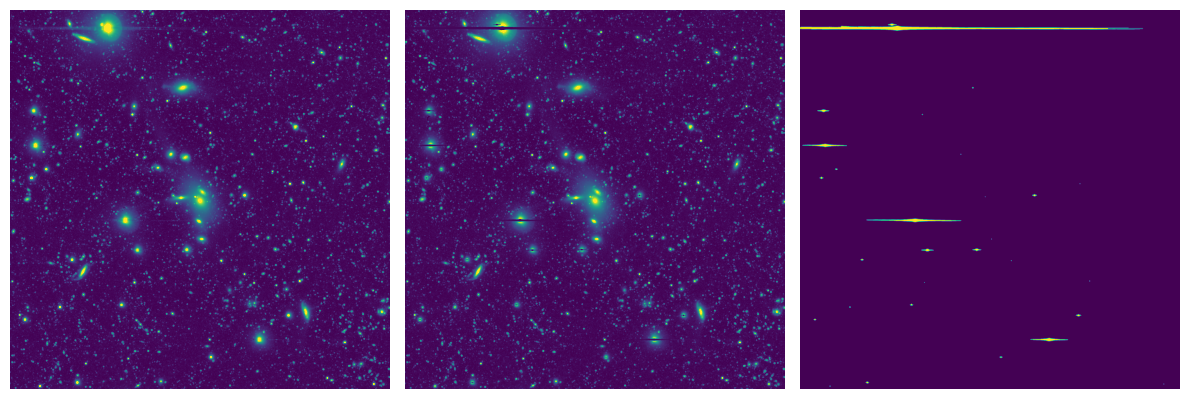

In [ ]:
plot_mask(img, bad_pixel_mask)

### Bright star mask

In [ ]:
#! exports
from nicl.hsc.preparation import fields

In [ ]:
#! exports
def find_field(coord):
    for f, bounds in fields.items():
        ra_low, ra_high, dec_low, dec_high = bounds
        if (ra_low < coord.ra) and (coord.ra < ra_high) and (dec_low < coord.dec) and (coord.dec < dec_high):
            return f

In [ ]:
#! exports
def get_pixel_scale(img):
    """Calculate the average pixel scale of the supplied image."""
    return (
        np.mean(
            [s.to_value("arcsec") for s in img.wcs.celestial.proj_plane_pixel_scales()]
        )
        * u.arcsec
    )


def get_img_centre_pixel(img):
    return (np.array(img.shape) - 1) / 2


def get_img_centre_world(img):
    """Calculate the world coordinates at the centre of the supplied image."""
    centre_pixel = get_img_centre_pixel(img)
    return img.wcs.pixel_to_world(*centre_pixel)


def distance_from_coord(shape, coord):
    """The distance from pixel `coord` to each pixel in an image with given `shape`."""
    ij = np.indices(shape)[::-1]
    coord = np.asarray(coord)[:, None, None]
    r = np.sqrt(((ij - coord) ** 2).sum(axis=0))
    return r

In [ ]:
#! exports
from os.path import join

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from astropy.table import QTable


def create_bright_star_mask(image, filter, z_cluster, r500_physical, data_path):
    """Get bright star mask regions that overlap the image."""
    pixel_size = get_pixel_scale(image)
    ylim, xlim = image.shape
    centre_coords = get_img_centre_world(image)
    field = find_field(centre_coords)
    bright_mask_data = QTable.read(
        join(data_path, f"{field}_{filter}_brightmaskdata.fits")
    )
    mask_centres = SkyCoord(bright_mask_data["ra"], bright_mask_data["dec"])
    bright_mask_data["x"], bright_mask_data["y"] = mask_centres.to_pixel(image.wcs)

    # find halo mask regions on the image
    halo_mask_data = bright_mask_data[bright_mask_data["shape"] == "circle"]
    radius_pix = halo_mask_data["width"] / pixel_size
    x, y = halo_mask_data["x"], halo_mask_data["y"]
    on_image_x = (x + radius_pix > 0) & (x - radius_pix < xlim)
    on_image_y = (y + radius_pix > 0) & (y - radius_pix < ylim)
    halo_mask_data = halo_mask_data[on_image_x & on_image_y]

    # Expand masks within R500 if does not overlap too much with BCG region.
    # This matches Jordan's analysis, but would probably be better to use
    # a fixed, justified, expansion factor.
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    deg_per_Mpc = 1 / cosmo.kpc_proper_per_arcmin(z_cluster).to(u.Mpc / u.deg)
    r500_angular = r500_physical * deg_per_Mpc
    bcg_extent_physical = 50 * u.kpc
    bcg_extent_angular = bcg_extent_physical * deg_per_Mpc
    bcg_extent_pixel = bcg_extent_angular / pixel_size
    r_bcg = distance_from_coord(image.shape, (np.array(img.shape) - 1) / 2)
    bcg_region = r_bcg <= bcg_extent_pixel
    bcg_region_size = bcg_region.sum()
    halo_mask = np.zeros(image.shape, bool)
    for m in halo_mask_data:
        radius_pix = m["width"] / pixel_size
        r = distance_from_coord(image.shape, (m["x"], m["y"]))
        r_mask_cluster = (
            centre_coords.separation(SkyCoord(m["ra"], m["dec"])) - m["width"]
        )
        if r_mask_cluster < r500_angular:
            for factor in (2.0, 1.5, 1.0):
                mask = r <= factor * radius_pix
                bcg_overlap = (mask & bcg_region).sum() / bcg_region_size
                if bcg_overlap < 0.2:
                    break
        else:
            mask = r <= radius_pix
        halo_mask[mask] = 1

    # find bloom mask regions on the image
    bloom_mask_data = bright_mask_data[bright_mask_data["shape"] == "box"]
    width_pix = radius_pix
    height_pix = bloom_mask_data["height"] / pixel_size
    x, y = bloom_mask_data["x"], bloom_mask_data["y"]
    on_image_x = (x + 0.5 * width_pix > 0) & (x - 0.5 * width_pix < xlim)
    on_image_y = (y + 0.5 * height_pix > 0) & (y - 0.5 * height_pix < ylim)
    bloom_mask_data = bloom_mask_data[on_image_x & on_image_y]
    bloom_mask = np.zeros(image.shape, bool)
    for m in bloom_mask_data:
        width_pix = 0.5 * m["width"] / pixel_size
        height_pix = 0.5 * m["height"] / pixel_size
        i, j = np.indices(image.shape)
        mask = (abs(i - m["y"]) <= height_pix) & (abs(j - m["x"]) <= width_pix)
        bloom_mask[mask] = 1

    joint_mask = halo_mask | bloom_mask
    return joint_mask

In [ ]:
bright_star_mask = create_bright_star_mask(
    image=img,
    filter=filter,
    z_cluster=cluster["z"],
    r500_physical=cluster["R_X"],
    data_path=local_data_path,
)

In [ ]:
print(
    f"Bright stars masked fraction: {100 * bright_star_mask.sum() / bright_star_mask.size:.2f}%"
)

Bright stars masked fraction: 7.76%


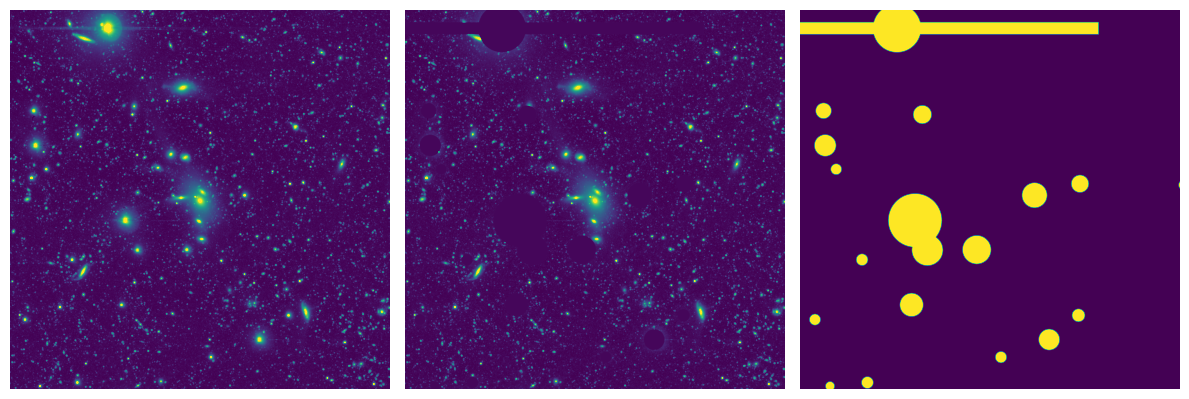

In [ ]:
plot_mask(img, bright_star_mask)

### Bright source mask

First we need to identify the BCG. The HSC-SSP images have an AB mag zeropoint of 27.

To convert the conventional B-band surface brightness limit to the observed band we use [ezgal](https://github.com/cmancone/easyGalaxy). As ezgal does not work correctly when installed via pip, and needs some data files and tweaks, we include a copy with nicl.

In [ ]:
#! exports
import nicl.ezgal as ezgal

from photutils.segmentation import detect_sources

def calc_kcorr(z, filter):
    """Calculate the kcorrection from restframe B-band to an observation in `filter`."""
    model = ezgal.model("bc03_ssp_z_0.02_chab.model")
    model.set_cosmology(Om=0.3, Ol=0.7, h=0.70, w=-1)
    zf = 3  # Redshift of formation, as in Furnell+21
    rest_b = model.get_absolute_mags(zf=zf, filters="B.dat", zs=z)
    obs_i = model.get_observed_absolute_mags(zf=zf, filters=filter, zs=z)
    kcorr = obs_i - rest_b
    return kcorr * u.mag


def calc_sb_threshold(z, filter, b_band_sb_threshold=25 * u.ABmag):
    k_corr = calc_kcorr(z, filter)
    dimming = 2.5 * np.log10((1 + z) ** 4) * u.mag
    return b_band_sb_threshold + k_corr + dimming


def sb_to_adu(sb, pix_scale, zp=27 * u.ABmag):
    sb_to_mag = sb - 2.5 * np.log10(pix_scale.to_value(u.arcsec) ** 2) * u.mag
    counts = 10 ** (-(sb_to_mag - zp).value / 2.5)
    return counts


def create_bcg_mask(image, threshold, bcg_pos=None):
    segm = detect_sources(
        data=image.data, threshold=threshold, npixels=detection_pars["detect_npixels"]
    )
    if bcg_pos is None:
        bcg_pos = get_img_centre_pixel(image).astype(int)
    bcg_label = segm.data[*bcg_pos[::-1]]
    bcg_mask = segm.data == bcg_label
    return bcg_mask

In [ ]:
sb_threshold = calc_sb_threshold(cluster["z"], 'hsc_i')
sb_adu_threshold = sb_to_adu(sb_threshold, get_pixel_scale(img))
sb_adu_threshold

0.5516939737703944

In [ ]:
bcg_mask = create_bcg_mask(img, sb_adu_threshold)

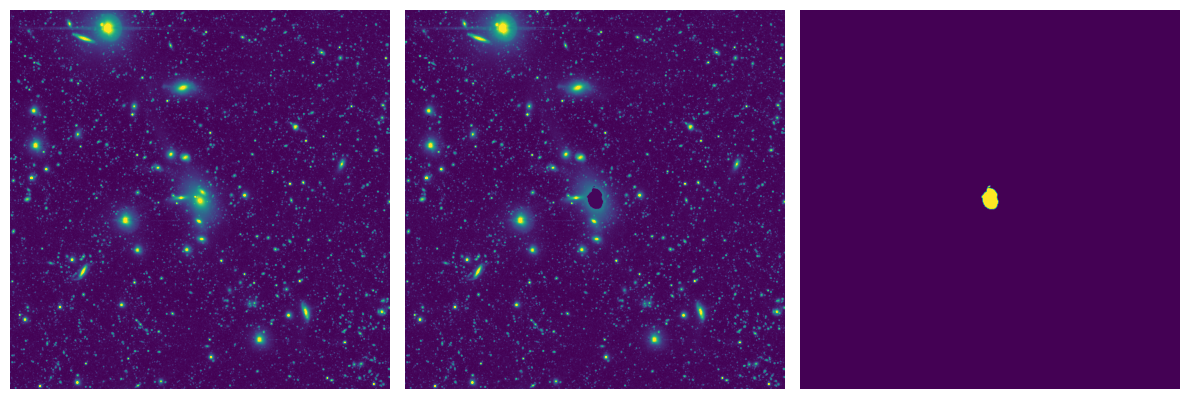

In [ ]:
plot_mask(img, bcg_mask)

In [ ]:
#| exports
from astropy.convolution import Gaussian2DKernel, convolve
from photutils.segmentation import deblend_sources, detect_sources, detect_threshold


def smooth_image(image, sigma):
    kernel = Gaussian2DKernel(sigma)
    kernel.normalize()
    smoothed = convolve(image.data, kernel)
    return smoothed


def create_object_mask(image, bcg_mask):
    threshold = detect_threshold(
        image.data,
        nsigma=3,
        background=0,
    )
    detection_image = smooth_image(image, sigma=1)
    segm = detect_sources(
        data=detection_image,
        threshold=threshold,
        npixels=6,
    )
    segm_deblend = deblend_sources(
        detection_image,
        segm,
        npixels=6,
        nlevels=32,
        contrast=0.01,
        progress_bar=False,
    )
    segm_deblend.remove_masked_labels(bcg_mask)
    obj_mask = segm_deblend.data > 0
    # TODO: dilate mask a bit
    return obj_mask

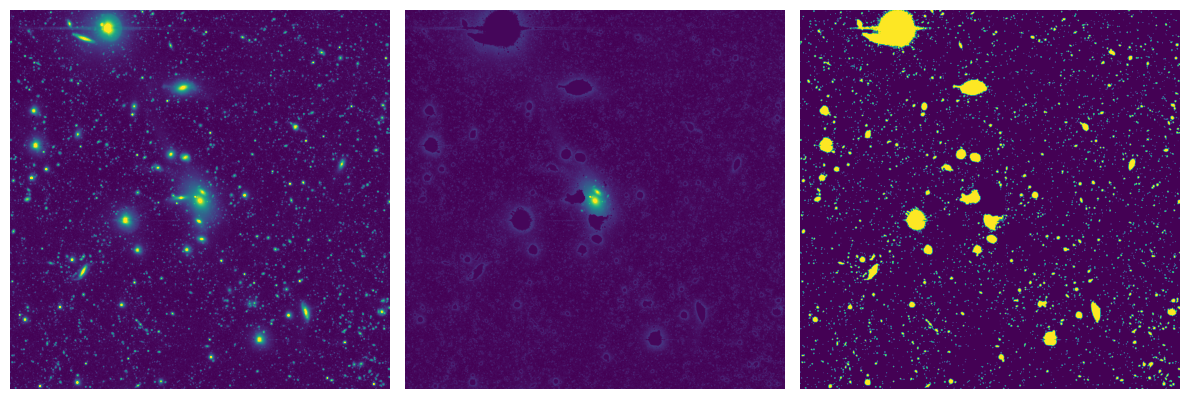

In [ ]:
object_mask = create_object_mask(img, bcg_mask)
plot_mask(img, object_mask)

In [ ]:
#|exports
from photutils.background import Background2D, MedianBackground


def create_faint_mask(image, bcg_mask, object_mask):
    bkg = Background2D(
        image.data,
        box_size=50,
        filter_size=1,
        sigma_clip=None,
        bkg_estimator=MedianBackground(),
    )
    threshold = detect_threshold(
        image.data,
        nsigma=2,
        background=bkg.background,
        error=bkg.background_rms
    )
    detection_image = smooth_image(image, sigma=1)
    segm = detect_sources(
        data=detection_image,
        threshold=threshold,
        npixels=4,
    )
    segm_deblend = deblend_sources(
        detection_image,
        segm,
        npixels=4,
        nlevels=128,
        contrast=0.001,
        progress_bar=False,
    )
    segm_deblend.remove_masked_labels(bcg_mask)  # better to just remove central source from mask, as above
    segm_deblend.remove_masked_labels(object_mask)
    faint_mask = segm_deblend.data > 0
    return faint_mask, bkg

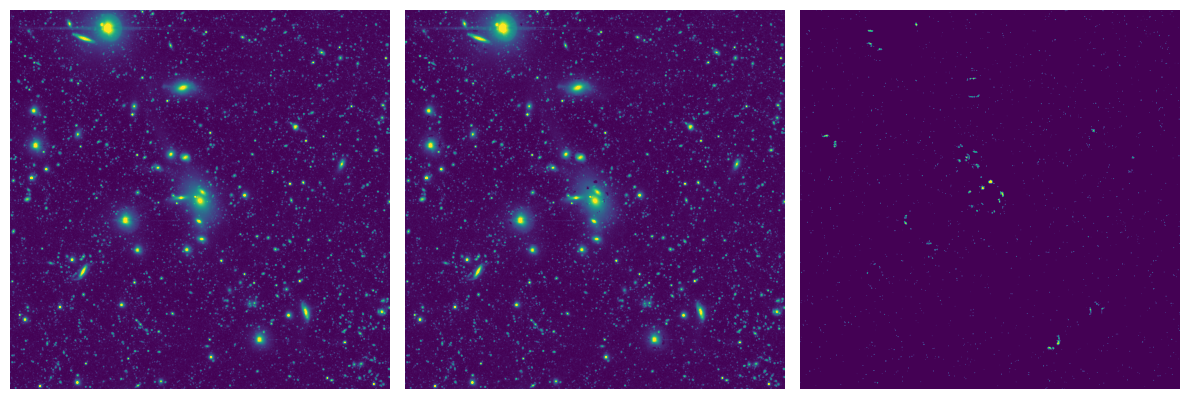

In [ ]:
#TODO: fix/improve this
faint_mask, bkg = create_faint_mask(img, bcg_mask, object_mask)
plot_mask(img, faint_mask)

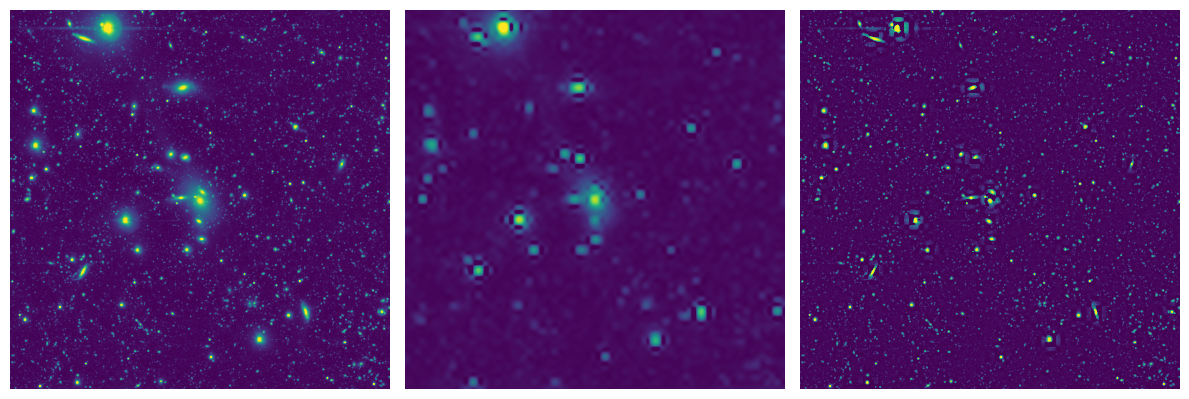

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
norm = ImageNormalize(vmin=-0.01, vmax=10, stretch=AsinhStretch(0.01))
ax[0].imshow(img, norm=norm)
ax[1].imshow(bkg.background, norm=norm)
ax[2].imshow(img - bkg.background, norm=norm)
for a in ax:
    a.axis("off")
plt.tight_layout()

Would be better to use a background method that doesn't leave such strong artefacts.

In [ ]:
full_mask = bad_pixel_mask | bright_star_mask | object_mask | faint_mask | bcg_mask

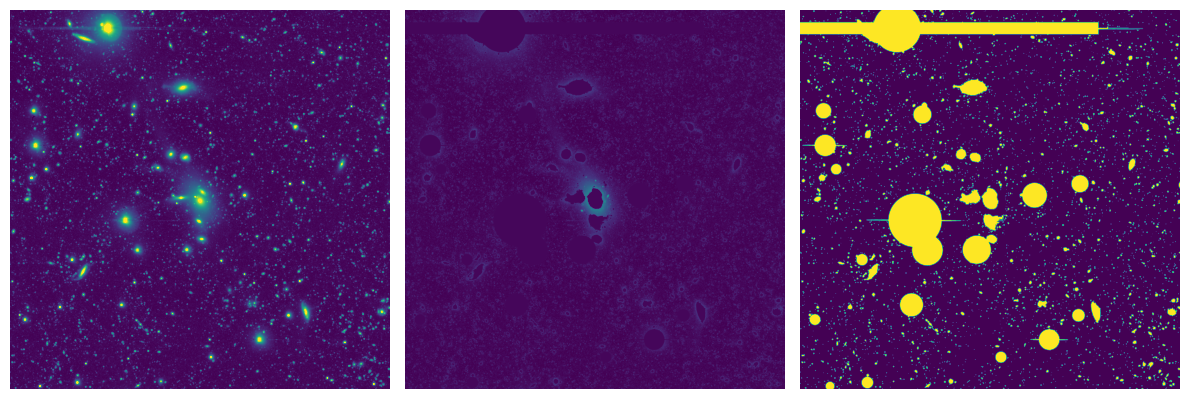

In [ ]:
plot_mask(img, full_mask)

In [ ]:
from astropy.io import fits

def write_mask(name, mask):
    fn = join(local_data_path, cluster["XCS ID"].replace(" ", "_"), f"{name}.fits")
    fits.writeto(fn, mask.astype("uint8"), overwrite=True, header=img.header)

In [ ]:
write_mask("bad_pixel_mask", bad_pixel_mask)
write_mask("bright_star_mask", bright_star_mask)
write_mask("bcg_mask", bcg_mask)
write_mask("object_mask", object_mask)
write_mask("faint_mask", faint_mask)
write_mask("full_mask", full_mask)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()